# Constitution d’un corpus TASS par scraping

Ce notebook sert à constituer un corpus d’articles publiés par l’agence TASS à partir de son endpoint de recherche. Il automatise la collecte des métadonnées minimales des articles — titre, URL et date de publication — sur une période donnée, en procédant jour par jour.

Le notebook est conçu pour un scraping long et potentiellement interrompu : il sauvegarde régulièrement l’avancement, évite les doublons, gère les erreurs temporaires de connexion ou de blocage, puis propose des vérifications simples sur le corpus obtenu. La dernière partie permet de contrôler la période couverte, de mesurer le nombre d’articles collectés et de visualiser la dynamique mensuelle du corpus.

## 1. Préparation de l’environnement

Cette section importe les bibliothèques nécessaires au notebook. Les modules standards servent à manipuler les fichiers JSON, les dates et les temporisations. Les bibliothèques externes sont utilisées pour envoyer les requêtes HTTP, stocker les résultats dans des tableaux, afficher une barre de progression et produire des visualisations.

In [2]:
# Bibliothèques standard
import json
import time
from datetime import datetime, date, timedelta
from collections import Counter

# Bibliothèques tierces
import requests
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # barre de progression compatible notebook
from requests.exceptions import RequestException, ConnectionError as ReqConnectionError

## 2. Paramètres de connexion à l’API TASS

Cette cellule définit l’adresse de l’endpoint de recherche TASS et les en-têtes HTTP utilisés pour les requêtes. L’ajout d’un `User-Agent` permet de formuler les requêtes comme provenant d’un navigateur ou d’un client identifiable, ce qui limite certains blocages côté serveur.

In [ ]:
# Endpoint de recherche TASS
BASE_URL = "https://tass.ru/tbp/api/v2/search"

# En-têtes HTTP minimum pour éviter un blocage côté serveur
HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; tass-parser-notebook/1.0)"
}

## 3. Gestion des erreurs temporaires

Le scraping peut être interrompu par des erreurs de connexion ou par des réponses de type `403`, qui indiquent souvent un blocage temporaire ou une limitation du nombre de requêtes. Cette exception personnalisée permet de distinguer ces problèmes récupérables des autres erreurs, afin de sauvegarder l’avancement et de relancer la collecte plus tard.

In [ ]:
# Exception métier: journée à relancer plus tard après trop d'erreurs API/réseau
class JourTemporairementBloque(Exception):
    """L’API TASS renvoie trop d’erreurs pour cette journée. À réessayer plus tard."""
    pass

## 4. Collecte des articles pour une période donnée

La fonction suivante interroge l’API TASS pour une fenêtre temporelle précise. Elle récupère les résultats page par page grâce au paramètre `offset`, gère les tentatives de relance en cas d’erreur temporaire, puis déduplique les articles à partir de leur identifiant.

À ce stade, la fonction renvoie les objets bruts récupérés depuis l’API. La sélection des champs utiles pour le corpus final est faite ensuite, lors du scraping jour par jour.

In [ ]:
def fetch_tass_by_period(from_date: str,
                         to_date: str,
                         limit: int = 30,
                         sleep_sec: float = 0.2,
                         retry_delay_403: float = 300.0,
                         retry_delay_conn: float = 60.0,
                         max_retries_403: int = 10,
                         max_retries_conn: int = 10):
    """Récupère tous les articles TASS pour une fenêtre temporelle donnée.

    La fonction pagine avec `offset`, gère les erreurs 403 et réseau avec retry,
    puis déduplique les résultats par identifiant d'article.
    """

    # État de pagination et de collecte
    offset = 0
    all_items = []
    seen_ids = set()
    total_count = None

    # Compteurs de tentatives pour les erreurs temporaires
    retries_403 = 0
    retries_conn = 0

    print(f"Chargement des articles : {from_date}  →  {to_date}")

    while True:
        # Paramètres envoyés à l'API
        params = {
            "search": "",
            "lang": "ru",
            "limit": limit,
            "offset": offset,
            "from_date": from_date,
            "to_date": to_date,
        }

        # Requête HTTP avec gestion des erreurs de connexion
        try:
            resp = requests.get(
                BASE_URL,
                params=params,
                headers=HEADERS,
                timeout=20
            )
        except (ReqConnectionError, RequestException) as e:
            retries_conn += 1
            print(f"Erreur de connexion pour offset={offset} (tentative #{retries_conn}) : {e}")

            if retries_conn > max_retries_conn:
                raise JourTemporairementBloque(
                    f"Trop d'erreurs de connexion pour la journée {from_date} → {to_date}"
                )

            print(f"Pause {retry_delay_conn} secondes avant un nouvel essai...")
            time.sleep(retry_delay_conn)
            continue

        # Connexion rétablie: on réinitialise le compteur réseau
        retries_conn = 0

        # Cas fréquent de rate limit / blocage temporaire
        if resp.status_code == 403:
            retries_403 += 1
            print(f"Code 403 pour offset={offset} (tentative #{retries_403})")

            if retries_403 > max_retries_403:
                raise JourTemporairementBloque(
                    f"Trop de réponses 403 pour la journée {from_date} → {to_date}"
                )

            print(f"Pause {retry_delay_403} secondes avant un nouvel essai...")
            time.sleep(retry_delay_403)
            continue

        # Autres erreurs HTTP non récupérables
        try:
            resp.raise_for_status()
        except requests.HTTPError as e:
            print(f"Erreur HTTP pour offset={offset} : {e}")
            print("Interruption du traitement de cette journée.")
            break

        # Extraction de la charge utile
        data = resp.json()
        result = data.get("result") or {}
        contents = result.get("contents") or []

        # Nombre total attendu (annoncé par l'API)
        if total_count is None:
            total_count = result.get("content_count")
            print(f"Nombre annoncé par l’API : {total_count}")

        # Plus de résultats => fin de pagination
        if not contents:
            print(f"offset={offset}: aucun résultat, arrêt pour cette journée.")
            break

        # Déduplication par id/composite_id
        new_items = []
        for item in contents:
            key = item.get("id") or item.get("composite_id")
            if key in seen_ids:
                continue
            seen_ids.add(key)
            new_items.append(item)

        all_items.extend(new_items)

        print(
            f"offset={offset} | reçus={len(contents)} | nouveaux={len(new_items)} | total collecté={len(all_items)}"
        )

        # Condition d'arrêt si on a atteint le total annoncé
        if total_count is not None and len(all_items) >= total_count:
            print("Nombre total atteint, fin de journée.")
            break

        # Page suivante
        offset += limit
        time.sleep(sleep_sec)

    print(f"Articles collectés pour cette journée: {len(all_items)}")
    return all_items

## 5. Scraping jour par jour, reprise et sauvegarde progressive

Cette section transforme la collecte ponctuelle en procédure de scraping sur une longue période. Le corpus est construit jour après jour, ce qui permet de mieux contrôler les interruptions et de reprendre la collecte depuis le dernier jour déjà traité.

La fonction vérifie les articles déjà présents dans le fichier de progression, évite les doublons à partir du couple `URL + date de publication`, sauvegarde les résultats après chaque journée et attend plus longtemps lorsqu’une journée est temporairement bloquée.

In [ ]:
def day_interval_for_tass(day: date):
    """Construit l'intervalle UTC attendu par l'API TASS pour une journée locale."""
    prev = day - timedelta(days=1)
    from_date = prev.strftime("%Y-%m-%dT23:00:00.000Z")
    to_date   = day.strftime("%Y-%m-%dT22:59:59.000Z")
    return from_date, to_date


def continuer_tass_scraping(
    all_minimal_items,
    start_day: date,
    end_day: date,
    json_path: str = "tass_minimal_progress.json",
    csv_path: str = "tass_minimal_progress.csv",
    limit: int = 30,
    sleep_sec: float = 0.2,
    long_sleep_if_blocked: float = 1800.0
):
    """Scrape jour par jour, reprend sur progression existante et sauvegarde en continu."""

    # Clés existantes pour éviter les doublons (url, datetime)
    existing_keys = set()
    # Dates déjà collectées pour reprendre au bon endroit
    existing_dates = set()

    for it in all_minimal_items:
        url = it.get("url")
        dt_str = it.get("published_dt")
        if url and dt_str:
            existing_keys.add((url, dt_str))
            try:
                existing_dates.add(datetime.fromisoformat(dt_str).date())
            except Exception:
                pass

    # Détermine la date de reprise
    if existing_dates:
        last_day = max(existing_dates)
        resume_day = max(start_day, last_day)
        print(f"Reprise depuis la date : {resume_day}")
    else:
        resume_day = start_day
        print(f"Début depuis la date initiale : {resume_day}")

    # Liste de toutes les journées à traiter
    days = []
    d = resume_day
    while d <= end_day:
        days.append(d)
        d += timedelta(days=1)

    print(f"Nombre de jours à traiter : {len(days)}")

    i = 0
    pbar = tqdm(total=len(days), desc="Jours", unit="jour")

    while i < len(days):
        day = days[i]
        from_date, to_date = day_interval_for_tass(day)

        print("---------------------------------------------")
        print(f"Jour en cours : {day}")
        print(f"Intervalle    : {from_date} → {to_date}")

        try:
            raw_items = fetch_tass_by_period(
                from_date=from_date,
                to_date=to_date,
                limit=limit,
                sleep_sec=sleep_sec
            )
        except JourTemporairementBloque as e:
            # En cas de blocage temporaire, on sauvegarde puis on attend longtemps
            print(f"Journée temporairement bloquée: {e}")
            print(f"Pause longue de {long_sleep_if_blocked} secondes avant nouvel essai...")

            try:
                with open(json_path, "w", encoding="utf-8") as f:
                    json.dump(all_minimal_items, f, ensure_ascii=False, indent=2)

                df_tmp = pd.DataFrame(all_minimal_items)
                df_tmp.to_csv(csv_path, sep=";", index=False, encoding="utf-8")

            except Exception:
                pass

            time.sleep(long_sleep_if_blocked)
            continue

        # Construit une version minimale des items et ajoute uniquement les nouveaux
        nouveaux = 0
        for it in raw_items:
            url_path = it.get("url") or it.get("content_url") or ""
            full_url = "https://tass.ru" + url_path
            pub = it.get("published_dt")

            key = (full_url, pub)
            if not pub or key in existing_keys:
                continue

            all_minimal_items.append({
                "title": it.get("title"),
                "url": full_url,
                "published_dt": pub,
            })
            existing_keys.add(key)
            nouveaux += 1

        print(f"Articles ajoutés pour ce jour : {nouveaux}")
        print(f"Total cumulé : {len(all_minimal_items)}")

        # Sauvegarde de sécurité après chaque journée
        try:
            with open(json_path, "w", encoding="utf-8") as f:
                json.dump(all_minimal_items, f, ensure_ascii=False, indent=2)

            print(f"Sauvegarde automatique effectuée : {json_path}")

        except Exception as e:
            print(f"Erreur lors de la sauvegarde : {e}")

        i += 1
        pbar.update(1)

    pbar.close()
    print("Traitement terminé.")
    print(f"Nombre total d'articles collectés : {len(all_minimal_items)}")

## 6. Lancement du scraping principal

Cette cellule charge un fichier de progression déjà existant, définit la période à couvrir, puis lance la collecte incrémentale. Dans ce notebook, la collecte commence au 18 février 2022 et se poursuit jusqu’à la date du jour.

Le résultat est sauvegardé progressivement dans `tass_minimal_progress.json`. Ce fichier constitue la base principale du corpus minimal.

In [ ]:
# Charge un fichier de progression existant pour reprendre le scraping
with open("tass_minimal_progress.json", "r", encoding="utf-8") as f:
    all_minimal_items = json.load(f)

# Fenêtre temporelle à couvrir
START_DAY = date(2022, 2, 18)
END_DAY = date.today()

# Lance le scraping incrémental
continuer_tass_scraping(
    all_minimal_items=all_minimal_items,
    start_day=START_DAY,
    end_day=END_DAY,
    json_path="tass_minimal_progress.json",
    limit=30,
    sleep_sec=0.5,                 # délai court entre pages
    long_sleep_if_blocked=1800     # 30 min avant de retenter une journée bloquée
)

JSONDecodeError: Expecting value: line 1794942 column 3 (char 69875818)

## 7. Réparation éventuelle d’un fichier JSON tronqué

Lors d’un scraping long, le fichier de progression peut être endommagé si l’exécution est interrompue au moment de l’écriture. La fonction suivante tente de récupérer tous les objets JSON complets encore lisibles dans le fichier.

Cette étape n’est pas nécessaire dans un déroulement normal. Elle sert de procédure de secours lorsque `tass_minimal_progress.json` ne peut plus être chargé directement comme une liste JSON valide.

In [ ]:
def rescue_broken_json_list(src_path: str, dst_path: str):
    """
    Tente de récupérer le maximum d'objets JSON valides depuis un fichier
    censé contenir une liste JSON [{...}, {...}, ...] mais tronqué/corrompu.

    Le résultat est écrit dans `dst_path` sous forme de liste JSON valide.
    """
    with open(src_path, "r", encoding="utf-8") as f:
        text = f.read()

    # Nettoyage basique des espaces en début/fin
    text = text.strip()

    if not text:
        print("Fichier vide.")
        return []

    # Retire les crochets de liste externes s'ils existent
    if text[0] == "[":
        text_body = text[1:]
    else:
        text_body = text

    if text_body.endswith("]"):
        text_body = text_body[:-1]

    items = []
    n = len(text_body)
    i = 0

    # Balayage caractère par caractère pour extraire les blocs { ... }
    while i < n:
        ch = text_body[i]

        # Cherche le début d'un objet
        if ch == "{":
            start = i
            depth = 1
            i += 1

            # Trouve l'accolade fermante correspondante au même niveau
            while i < n and depth > 0:
                if text_body[i] == "{":
                    depth += 1
                elif text_body[i] == "}":
                    depth -= 1
                i += 1

            if depth == 0:
                obj_str = text_body[start:i]  # de { à }

                try:
                    obj = json.loads(obj_str)
                    items.append(obj)
                except json.JSONDecodeError:
                    # Objet partiel/invalide: on le saute
                    pass

            else:
                # Fichier coupé en plein objet: on arrête
                break
        else:
            i += 1

    print(f"Objets restaurés avec succès: {len(items)}")

    # Sauvegarde de la liste réparée
    with open(dst_path, "w", encoding="utf-8") as f_out:
        json.dump(items, f_out, ensure_ascii=False, indent=2)

    print(f"La liste corrigée est enregistrée dans: {dst_path}")
    return items

## 8. Application de la réparation

Cette cellule applique la fonction de récupération au fichier de progression principal. Les objets restaurés sont enregistrés dans un nouveau fichier, `tass_minimal_progress_fixed.json`, afin de conserver une version réparée sans écraser immédiatement le fichier initial.

La dernière date disponible est ensuite affichée pour vérifier jusqu’où le corpus a pu être restauré.

In [ ]:
# Répare un JSON tronqué et écrit une version nettoyée
fixed_items = rescue_broken_json_list(
    src_path="tass_minimal_progress.json",
    dst_path="tass_minimal_progress_fixed.json"
)

# Vérifie la dernière date disponible si la liste n'est pas vide
if fixed_items:
    last_dt = fixed_items[-1].get("published_dt")
    print("Dernier published_dt:", last_dt)
else:
    print("Aucun élément restauré.")

Objets restaurés avec succès: 1175113
La liste corrigée est enregistrée dans: tass_minimal_progress_fixed.json
Dernier published_dt: 2025-12-09T23:01:30


## 9. Reprise du scraping à partir du fichier réparé

Après réparation, le notebook peut reprendre la collecte à partir du fichier restauré. Cette étape recharge `tass_minimal_progress_fixed.json`, puis relance le scraping incrémental en sauvegardant de nouveau les résultats dans `tass_minimal_progress.json`.

Elle permet donc de continuer la constitution du corpus sans repartir de zéro.

In [ ]:
# Reprend le scraping depuis le fichier réparé
with open("tass_minimal_progress_fixed.json", "r", encoding="utf-8") as f:
    all_minimal_items = json.load(f)

# Fenêtre temporelle à couvrir
START_DAY = date(2022, 2, 18)
END_DAY = date.today()

# Lance le scraping incrémental
continuer_tass_scraping(
    all_minimal_items=all_minimal_items,
    start_day=START_DAY,
    end_day=END_DAY,
    json_path="tass_minimal_progress.json",
    limit=30,
    sleep_sec=0.5,                 # délai court entre pages
    long_sleep_if_blocked=1800     # 30 min avant de retenter une journée bloquée
)

Reprise depuis la date : 2025-12-10
Nombre de jours à traiter : 2


Jours:   0%|          | 0/2 [00:00<?, ?jour/s]

---------------------------------------------
Jour en cours : 2025-12-10
Intervalle    : 2025-12-09T23:00:00.000Z → 2025-12-10T22:59:59.000Z
Chargement des articles : 2025-12-09T23:00:00.000Z  →  2025-12-10T22:59:59.000Z
Nombre annoncé par l’API : 1235
offset=0 | reçus=30 | nouveaux=30 | total collecté=30
offset=30 | reçus=30 | nouveaux=30 | total collecté=60
offset=60 | reçus=30 | nouveaux=30 | total collecté=90
offset=90 | reçus=30 | nouveaux=30 | total collecté=120
offset=120 | reçus=30 | nouveaux=30 | total collecté=150
offset=150 | reçus=30 | nouveaux=30 | total collecté=180
offset=180 | reçus=30 | nouveaux=30 | total collecté=210
offset=210 | reçus=30 | nouveaux=30 | total collecté=240
offset=240 | reçus=30 | nouveaux=30 | total collecté=270
offset=270 | reçus=30 | nouveaux=30 | total collecté=300
offset=300 | reçus=30 | nouveaux=30 | total collecté=330
offset=330 | reçus=30 | nouveaux=30 | total collecté=360
offset=360 | reçus=30 | nouveaux=30 | total collecté=390
offset=390 | r

## 10. Vérification et description du corpus téléchargé

Les cellules suivantes contrôlent le corpus minimal obtenu après scraping. Elles permettent de vérifier le volume d’articles, la période couverte, la distribution quotidienne des publications et l’évolution mensuelle du nombre d’articles collectés.

### 10.1. Imports complémentaires pour les statistiques

Cette cellule recharge les modules nécessaires à l’analyse descriptive du fichier JSON : lecture des données, conversion des dates et comptage des articles par période.

In [ ]:
import json
from datetime import datetime
from collections import Counter

### 10.2. Vérification de la période couverte

Cette étape charge le fichier `tass_minimal_progress.json`, extrait les dates de publication disponibles et identifie la date la plus ancienne et la date la plus récente du corpus. Elle permet de vérifier rapidement si la période collectée correspond bien à la période attendue.

In [ ]:
# Analyse simple de la période couverte par le corpus
json_path = "tass_minimal_progress.json"

# ============================================================
# 1. Chargement du fichier
# ============================================================
with open(json_path, "r", encoding="utf-8") as f:
    items = json.load(f)

print(f"Fichier chargé : {json_path}")
print(f"Nombre total d'articles : {len(items)}")

# ============================================================
# 2. Extraction des dates de publication
# ============================================================
dates = []

for it in items:
    dt_str = it.get("published_dt")
    if not dt_str:
        continue
    try:
        # `published_dt` est au format ISO 8601
        dt = datetime.fromisoformat(dt_str.replace("Z", "+00:00"))
        dates.append(dt)
    except Exception:
        pass

if not dates:
    raise ValueError("Aucune date valide n'a pu être extraite du fichier.")

# ============================================================
# 3. Période couverte par le corpus
# ============================================================
date_min = min(dates)
date_max = max(dates)

print("\nPériode couverte par le corpus :")
print(f"Date la plus ancienne : {date_min}")
print(f"Date la plus récente  : {date_max}")
print(f"Nombre total d'articles : {len(items)}")

# Affichage optionnel sans composante horaire
print("\nPériode (dates uniquement) :")
print(f"Du {date_min.date()} au {date_max.date()}")

Fichier chargé : tass_minimal_progress.json
Nombre total d'articles : 1176210

Période couverte par le corpus :
Date la plus ancienne : 2022-02-17 23:05:47
Date la plus récente  : 2025-12-11 16:23:29
Nombre total d'articles : 1176210

Période (dates uniquement) :
Du 2022-02-17 au 2025-12-11


### 10.3. Contrôle du nombre d’articles par jour

Cette cellule compte le nombre d’articles collectés pour chaque date de publication. Elle permet de repérer les jours avec un très faible ou très fort nombre d’articles et d’identifier d’éventuelles anomalies dans la collecte.

La première date est exclue du calcul, car elle peut correspondre à une journée incomplète selon la fenêtre temporelle utilisée au début du scraping.

In [3]:


json_path = "tass_minimal_progress.json"

# 1. Chargement du fichier

with open(json_path, "r", encoding="utf-8") as f:
    items = json.load(f)

print(f"Fichier chargé : {json_path}")
print(f"Nombre total d'articles : {len(items)}")

# 2. Extraction des dates (jour uniquement) + comptage

day_counts = Counter()

for it in items:
    dt_str = it.get("published_dt")
    if not dt_str:
        continue
    try:
        dt = datetime.fromisoformat(dt_str.replace("Z", "+00:00"))
        day = dt.date()
        day_counts[day] += 1
    except Exception:
        pass

if not day_counts:
    raise ValueError("Aucune date valide n'a pu être extraite du fichier.")

# 3. Ignorer la première date (la plus ancienne)

first_day = min(day_counts.keys())
day_counts.pop(first_day, None)

if not day_counts:
    raise ValueError("Après suppression de la première date, il ne reste plus de données.")

print(f"\nLa première date {first_day} a été ignorée.")

# 4. Min / Max количество статей за день

min_count = min(day_counts.values())
max_count = max(day_counts.values())

min_days = [d for d, c in day_counts.items() if c == min_count]
max_days = [d for d, c in day_counts.items() if c == max_count]

print("\nStatistiques sur les articles par jour (sans la première date) :")
print(f"Minimum d'articles par jour : {min_count} (jours : {len(min_days)})")
print("Dates avec minimum :", ", ".join(str(d) for d in sorted(min_days)))

print(f"\nМаксимум статей за день : {max_count} (дней: {len(max_days)})")
print("Даты с максимумом:", ", ".join(str(d) for d in sorted(max_days)))


date_min = min(day_counts.keys())
date_max = max(day_counts.keys())

print("\nПериод (только даты) после удаления первой даты:")
print(f"Du {date_min} au {date_max}")


Fichier chargé : tass_minimal_progress.json
Nombre total d'articles : 1176210

La première date 2022-02-17 a été ignorée.

Statistiques sur les articles par jour (sans la première date) :
Minimum d'articles par jour : 249 (jours : 1)
Dates avec minimum : 2023-01-01

Максимум статей за день : 1819 (дней: 1)
Даты с максимумом: 2024-06-06

Период (только даты) после удаления первой даты:
Du 2022-02-18 au 2025-12-11


### 10.4. Agrégation mensuelle et visualisation

Cette dernière étape agrège les articles par mois afin d’observer la dynamique globale du corpus. Le graphique représente le nombre total d’articles collectés par mois, en excluant le premier et le dernier mois lorsqu’ils sont potentiellement incomplets.

Le graphique est également sauvegardé sous forme d’image PNG pour pouvoir être réutilisé dans un document de travail ou dans le mémoire.


Statistiques par jour :
Période : du 2022-02-17 au 2025-12-11 (inclus)
Nombre de jours dans la période : 1394
Nombre de jours avec au moins 1 article : 1394
Moyenne d'articles par jour (incluant les jours à 0) : 843.766
Moyenne d'articles par jour (seulement jours actifs) : 843.766

Statistiques par mois :
Nombre de mois couverts : 47
Mois min : 2022-02 | Mois max : 2025-12


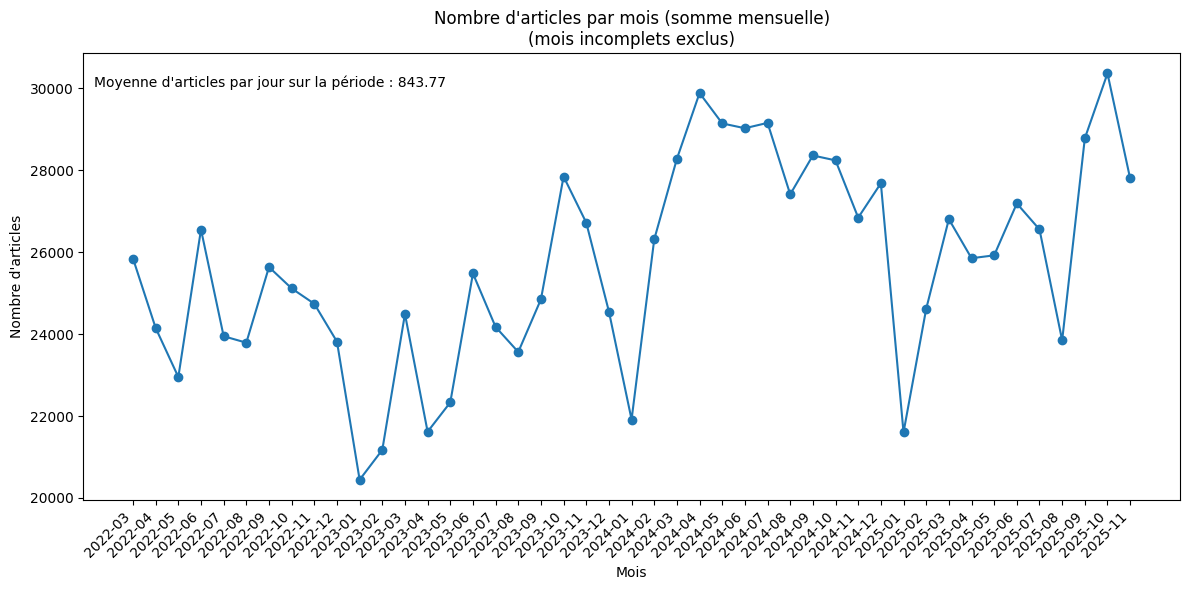

In [4]:
# Dictionnaire {date -> nombre d'articles ce jour-là}
day_counter = Counter()
# Liste de tous les datetime valides (sert à trouver la période min/max)
dt_list = []

# Parcours de tous les items pour extraire et convertir la date de publication
for it in items:
    dt_str = it.get("published_dt")
    # Si la date n'existe pas, on ignore l'item
    if not dt_str:
        continue
    try:
        # Conversion ISO; remplace 'Z' (UTC) par le format attendu par fromisoformat
        dt = datetime.fromisoformat(dt_str.replace("Z", "+00:00"))
        dt_list.append(dt)
        # Incrémente le compteur pour le jour correspondant
        day_counter[dt.date()] += 1
    except Exception:
        # Si le format de date est invalide, on ignore simplement cet item
        pass

# Sécurité : on arrête si aucune date n'a pu être parsée
if not dt_list:
    raise ValueError("Aucune date valide n'a pu être extraite (published_dt).")

# Début et fin de la période couverte par les données
min_day = min(d.date() for d in dt_list)
max_day = max(d.date() for d in dt_list)

# Série complète de jours (inclut aussi les jours sans article, donc à 0)
all_days = []
d = min_day
while d <= max_day:
    all_days.append(d)
    d += timedelta(days=1)

# Nombre d'articles pour chaque jour de la période complète
counts_per_day_full = [day_counter.get(d, 0) for d in all_days]

# Moyennes globales
total_days_in_period = len(all_days)
total_articles = sum(counts_per_day_full)
# Moyenne sur tous les jours (y compris jours à 0)
avg_per_day_full = total_articles / total_days_in_period

# Jours "actifs" = jours avec au moins un article
active_days = [d for d in all_days if day_counter.get(d, 0) > 0]
# Moyenne uniquement sur les jours actifs
avg_per_active_day = total_articles / len(active_days) if active_days else 0.0

# Affichage des statistiques quotidiennes
print("\nStatistiques par jour :")
print(f"Période : du {min_day} au {max_day} (inclus)")
print(f"Nombre de jours dans la période : {total_days_in_period}")
print(f"Nombre de jours avec au moins 1 article : {len(active_days)}")
print(f"Moyenne d'articles par jour (incluant les jours à 0) : {avg_per_day_full:.3f}")
print(f"Moyenne d'articles par jour (seulement jours actifs) : {avg_per_active_day:.3f}")

# ------------------------------------------------------------
# 3) Agrégation mensuelle (format YYYY-MM)
# ------------------------------------------------------------
month_counter = Counter()
for d, c in day_counter.items():
    month_key = f"{d.year:04d}-{d.month:02d}"
    month_counter[month_key] += c

# Tri chronologique des mois
months_sorted = sorted(month_counter.keys())
month_counts = [month_counter[m] for m in months_sorted]

# Affichage des statistiques mensuelles
print("\nStatistiques par mois :")
print(f"Nombre de mois couverts : {len(months_sorted)}")
print(f"Mois min : {months_sorted[0]} | Mois max : {months_sorted[-1]}")

# ------------------------------------------------------------
# 4) Graphique : somme mensuelle dans le temps
#    (on exclut le 1er et le dernier mois, souvent incomplets)
# ------------------------------------------------------------
if len(months_sorted) > 2:
    months_plot = months_sorted[1:-1]
    counts_plot = month_counts[1:-1]
else:
    raise ValueError("Pas assez de mois complets pour construire le graphique.")

# Tracé de la courbe mensuelle
plt.figure(figsize=(12, 6))
plt.plot(months_plot, counts_plot, marker="o")

plt.title("Nombre d'articles par mois (somme mensuelle)\n(mois incomplets exclus)")
plt.xlabel("Mois")
plt.ylabel("Nombre d'articles")
plt.xticks(rotation=45, ha="right")

# Prépare un texte affichant la moyenne journalière sur la période
text_avg = (
    f"Moyenne d'articles par jour sur la période : "
    f"{avg_per_day_full:.2f}"
)

# Affiche le texte dans le coin supérieur gauche du graphique
plt.text(
    0.01, 0.95,
    text_avg,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    fontsize=10
)

plt.tight_layout()

# Sauvegarde le graphique en PNG haute résolution
plt.savefig("tass_articles_par_mois_mois_complets.png", dpi=300)

# Affiche la figure à l'écran
plt.show()